# Brain Tumor MRI Classification — Pretrained vs Fine-Tuned Comparison
### VGG16 · EfficientNetB0 · ConvNeXt-Tiny

This notebook trains and evaluates **three transfer-learning architectures** on the same brain tumor MRI dataset, using the **same configuration** (image size, split, batch size, epochs) for a fair comparison:

1. **Part A — Pretrained (Frozen Backbone)**: only a small classification head is trained on top of frozen ImageNet weights, for all three models.
2. **Part B — Fine-Tuned**: starting from each frozen model, the last N backbone layers are unfrozen and retrained at a lower learning rate.

**Dataset:** 8,961 MRI images across 4 classes — Meningioma (3,792), Glioma (3,123), Pituitary (1,138), No Tumor/Healthy (908). Uploaded from the browser as a class-wise working copy (see the Quality Control Report in Step 2b).


## Step 0 — Setup: Clear Session, Imports, Upload Dataset (Browser)

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

tf.keras.backend.clear_session()
gc.collect()
print('Session cleared. Libraries imported.')


Session cleared. Libraries imported.


In [2]:
# ============================================================
#  DATASET INPUT — upload the class-wise dataset folder from your
#  local machine via the browser (no Kaggle/Drive path needed).
#
#  1) Zip the class-wise dataset folder on your computer first, e.g.:
#       Brain Tumour_Final Dataset_Classwise.zip
#       ├── Glioma/            (Image_001.jpg ... Image_3123.jpg)
#       ├── Meningioma/        (Image_001.jpg ... Image_3792.jpg)
#       ├── No Tumor/          (Image_001.jpg ... Image_908.jpg)
#       └── Pituitary/         (Image_001.jpg ... Image_1138.jpg)
#  2) Run this cell — a browser file-picker will open, choose the zip.
# ============================================================
from google.colab import files
import zipfile

print('Choose the dataset ZIP file to upload...')
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
EXTRACT_DIR = '/content/dataset'
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

# If the zip contained a single top-level folder, drill into it automatically
entries = [e for e in os.listdir(EXTRACT_DIR) if not e.startswith('__MACOSX') and not e.startswith('.')]
if len(entries) == 1 and os.path.isdir(os.path.join(EXTRACT_DIR, entries[0])):
    DATASET_DIR = os.path.join(EXTRACT_DIR, entries[0])
else:
    DATASET_DIR = EXTRACT_DIR

print('Dataset extracted to:', DATASET_DIR)
print('Folders found:', sorted(os.listdir(DATASET_DIR)))


Choose the dataset ZIP file to upload...


Saving Brain Tumour_Final Dataset_Classwise.zip to Brain Tumour_Final Dataset_Classwise.zip
Dataset extracted to: /content/dataset/Brain Tumour_Final Dataset_Classwise
Folders found: ['Glioma', 'Meningioma', 'No Tumor or Healthy', 'Pituitary']


## Step 1 — Configuration

All models below share this exact configuration, so results are directly comparable. Only the model-specific preprocessing function changes per architecture.

In [3]:
# ============================================================
#  SHARED CONFIGURATION — used identically by all 3 models
# ============================================================
# DATASET_DIR is set by the upload cell in Step 0. This fallback only
# matters if you skip that cell and mount the folder some other way.
DATASET_DIR = DATASET_DIR if 'DATASET_DIR' in globals() else '/content/dataset'

IMG_SIZE    = 224
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
BATCH_SIZE  = 16
SEED        = 125

# Stratified train / val / test split
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15
assert abs((TRAIN_SPLIT + VAL_SPLIT + TEST_SPLIT) - 1.0) < 1e-6

# Training schedule (identical for every model)
HEAD_EPOCHS       = 20   # Part A: frozen-backbone / head-only training
FINETUNE_EPOCHS   = 15   # Part B: fine-tuning after unfreezing
HEAD_LR           = 1e-4
FINETUNE_LR       = 1e-5
UNFREEZE_LAST_N   = 30   # number of trailing backbone layers unfrozen for fine-tuning

# Expected class distribution — from the Quality Control Report on the
# class-wise working dataset (post-cleanup/dedup), total = 8,961 images
EXPECTED_COUNTS = {
    'Glioma':     3123,  # was 3,192 before duplicate removal
    'Meningioma': 3792,  # unchanged, no duplicates found
    'Pituitary':  1138,  # was 1,147 before duplicate removal
    'No Tumor':    908,  # unchanged, no duplicates found
}
# Total working dataset after cleanup: 3,123 + 3,792 + 1,138 + 908 = 8,961 images

print(f'Image size   : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Split        : {TRAIN_SPLIT:.0%} / {VAL_SPLIT:.0%} / {TEST_SPLIT:.0%} (train/val/test)')
print(f'Head epochs  : {HEAD_EPOCHS}  |  Fine-tune epochs: {FINETUNE_EPOCHS}')


Image size   : 224x224
Batch size   : 16
Split        : 70% / 15% / 15% (train/val/test)
Head epochs  : 20  |  Fine-tune epochs: 15


## Step 2 — Build the Dataframe & Verify Class Distribution

Walks `DATASET_DIR/<class>/...` and builds a `filepaths` / `labels` dataframe, then checks the counts against the expected distribution.

In [4]:
classes = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
class_count = len(classes)
print('Classes found:', classes)

filepaths, labels = [], []
for klass in classes:
    classpath = os.path.join(DATASET_DIR, klass)
    for f in os.listdir(classpath):
        filepaths.append(os.path.join(classpath, f))
        labels.append(klass)

df = pd.concat([pd.Series(filepaths, name='filepaths'),
                pd.Series(labels, name='labels')], axis=1)

print(f'\nTotal images loaded: {len(df)}')
counts = df['labels'].value_counts()
print('\nClass distribution (found vs expected):')
for cls in classes:
    found = counts.get(cls, 0)
    expected = EXPECTED_COUNTS.get(cls, 'N/A')
    print(f'  {cls:12s}: found={found:5d}   expected={expected}')


Classes found: ['Glioma', 'Meningioma', 'No Tumor or Healthy', 'Pituitary']

Total images loaded: 8961

Class distribution (found vs expected):
  Glioma      : found= 3123   expected=3123
  Meningioma  : found= 3792   expected=3792
  No Tumor or Healthy: found=  908   expected=N/A
  Pituitary   : found= 1138   expected=1138


## Step 2b — Technical Validation (Class-Wise Dataset QC)

**Important dataset note:** this working copy is organized **class-wise** for training — each class folder contains flat, sequentially-numbered images (`Image_001.jpg`, `Image_002.jpg`, ...) with no per-patient subfolders. The publicly released dataset keeps the original **patient-wise** organization; this class-wise copy is only a computational working copy prepared for model development.

For each class we validate:
- **Filename sequence** — first/last image number, and any gaps (missing sequence positions)
- **Invalid filenames** — files that don't match the `Image_NNN.jpg` pattern
- **Exact duplicates** — byte-identical files, detected via SHA-256 content hashing
- **Overall QC status** — PASS only if no missing positions, no invalid filenames, and the class-wise total matches the expected count


In [5]:
import re
import hashlib
from collections import defaultdict

IMAGE_FILENAME_RE = re.compile(r'^Image_(\d+)\.jpg$', re.IGNORECASE)


def sha256_hash(path, block_size=65536):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(block_size), b''):
            h.update(block)
    return h.hexdigest()


def validate_class_folder(class_path):
    """Class-wise QC: sequential filename check + SHA-256 duplicate check."""
    numbers = []
    invalid_filenames = 0
    hashes = defaultdict(list)

    for fname in sorted(os.listdir(class_path)):
        fpath = os.path.join(class_path, fname)
        if not os.path.isfile(fpath):
            continue

        m = IMAGE_FILENAME_RE.match(fname)
        if not m:
            invalid_filenames += 1
            continue

        numbers.append(int(m.group(1)))
        hashes[sha256_hash(fpath)].append(fpath)

    numbers.sort()
    count = len(numbers)
    first_number = numbers[0] if numbers else None
    last_number = numbers[-1] if numbers else None

    # Missing sequence positions: gaps between first and last number
    missing_positions = 0
    if numbers:
        expected_set = set(range(first_number, last_number + 1))
        missing_positions = len(expected_set - set(numbers))

    duplicate_groups = [paths for paths in hashes.values() if len(paths) > 1]
    duplicate_entries = sum(len(paths) - 1 for paths in duplicate_groups)

    return {
        'Class': os.path.basename(class_path),
        'Count': count,
        'First Number': first_number,
        'Last Number': last_number,
        'Missing Sequence Positions': missing_positions,
        'Invalid Filenames': invalid_filenames,
        'Duplicate Groups': len(duplicate_groups),
        'Duplicate Entries': duplicate_entries,
    }


class_folders = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
class_reports = [validate_class_folder(os.path.join(DATASET_DIR, c)) for c in class_folders]

total_images = sum(r['Count'] for r in class_reports)

print('QUALITY CONTROL REPORT')
print('Bangladeshi Brain Tumor MRI Dataset — Class-wise Working Dataset')
print('=' * 70)
print(f'\nDataset Directory: {DATASET_DIR}')
print('\nDATASET SUMMARY')
print(f'Total Images: {total_images:,}')
print(f'Total Classes: {len(class_reports)}')
print('Organization: Class-wise')
print('Image Format: JPEG (.jpg)')

print('\nCLASS-WISE DISTRIBUTION')
for r in class_reports:
    print(f"\n{r['Class']}")
    print(f"Images: {r['Count']:,}")
    print(f"First Image: Image_{r['First Number']:03d}.jpg")
    print(f"Last Image: Image_{r['Last Number']}.jpg")

print('\nFILENAME VALIDATION')
for r in class_reports:
    print(f"\n{r['Class']}:")
    print(f"Count: {r['Count']:,}")
    print(f"First Number: {r['First Number']}")
    print(f"Last Number: {r['Last Number']:,}")
    print(f"Missing Sequence Positions: {r['Missing Sequence Positions']}")
    print(f"Invalid Filenames: {r['Invalid Filenames']}")

total_dup_groups = sum(r['Duplicate Groups'] for r in class_reports)
total_dup_entries = sum(r['Duplicate Entries'] for r in class_reports)

print('\nDUPLICATE CHECK')
print('Exact-duplicate detection was performed using SHA-256 file-content hashing.')
print(f'Current pass found {total_dup_groups} duplicate group(s) and {total_dup_entries} duplicate image-file entry(ies).')
# Historical reference (pre-cleanup, from the original QC pass): 78 duplicate
# groups / 156 duplicate image-file entries, resolved down to 8,961 images.

qc_pass = all(
    r['Missing Sequence Positions'] == 0 and r['Invalid Filenames'] == 0
    for r in class_reports
) and total_dup_entries == 0

print('\nFINAL QC STATUS')
print(f"Overall Status: {'PASS' if qc_pass else 'FAIL'}")


QUALITY CONTROL REPORT
Bangladeshi Brain Tumor MRI Dataset — Class-wise Working Dataset

Dataset Directory: /content/dataset/Brain Tumour_Final Dataset_Classwise

DATASET SUMMARY
Total Images: 8,961
Total Classes: 4
Organization: Class-wise
Image Format: JPEG (.jpg)

CLASS-WISE DISTRIBUTION

Glioma
Images: 3,123
First Image: Image_001.jpg
Last Image: Image_3123.jpg

Meningioma
Images: 3,792
First Image: Image_001.jpg
Last Image: Image_3792.jpg

No Tumor or Healthy
Images: 908
First Image: Image_001.jpg
Last Image: Image_908.jpg

Pituitary
Images: 1,138
First Image: Image_001.jpg
Last Image: Image_1138.jpg

FILENAME VALIDATION

Glioma:
Count: 3,123
First Number: 1
Last Number: 3,123
Missing Sequence Positions: 0
Invalid Filenames: 0

Meningioma:
Count: 3,792
First Number: 1
Last Number: 3,792
Missing Sequence Positions: 0
Invalid Filenames: 0

No Tumor or Healthy:
Count: 908
First Number: 1
Last Number: 908
Missing Sequence Positions: 0
Invalid Filenames: 0

Pituitary:
Count: 1,138
Firs

In [6]:
# ------------------------------------------------------------
# Class-Wise Summary Table (from the QC pass above)
# ------------------------------------------------------------
summary_df = pd.DataFrame(class_reports)[
    ['Class', 'Count', 'First Number', 'Last Number', 'Missing Sequence Positions', 'Invalid Filenames']
]

total_row = {
    'Class': 'TOTAL',
    'Count': summary_df['Count'].sum(),
    'First Number': '—',
    'Last Number': '—',
    'Missing Sequence Positions': summary_df['Missing Sequence Positions'].sum(),
    'Invalid Filenames': summary_df['Invalid Filenames'].sum(),
}
summary_df = pd.concat([summary_df, pd.DataFrame([total_row])], ignore_index=True)

# Sanity check against the Quality Control Report totals (8,961 images)
assert total_row['Count'] == 8961, f"Total image count {total_row['Count']} != expected 8,961"

summary_df


,Class,Count,First Number,Last Number,Missing Sequence Positions,Invalid Filenames
0,Glioma,3123,1,3123,0,0
1,Meningioma,3792,1,3792,0,0
2,No Tumor or Healthy,908,1,908,0,0
3,Pituitary,1138,1,1138,0,0
4,TOTAL,8961,—,—,0,0


### Validation Outcome

The class-wise working dataset contains **8,961** JPEG MRI images across four diagnostic classes: Glioma (3,123), Meningioma (3,792), Pituitary (1,138), and No Tumor/Healthy (908). Class-wise image counts and sequential filename organization were validated with no missing sequence positions or invalid filenames.

An earlier duplicate-detection pass (SHA-256 hashing) had identified 78 duplicate groups / 156 duplicate image-file entries; these have since been removed, and the current filesystem reflects the post-cleanup count of 8,961 images.

**Note:** this class-wise directory is a computational working copy prepared for model development and technical validation. The publicly released dataset retains its original **patient-wise** organization — the class-wise working copy should not be treated as the repository structure of the released dataset.

**Preliminary classification accuracy (pending final training run): X%**


## Step 3 — Stratified 70 / 15 / 15 Split

`stratify=` keeps the class proportions consistent across train/val/test — important here since **Normal** is a small minority class (142 images, ~2.4%).

In [7]:
train_df, temp_df = train_test_split(
    df, train_size=TRAIN_SPLIT, stratify=df['labels'], shuffle=True, random_state=SEED
)
val_ratio_of_temp = VAL_SPLIT / (VAL_SPLIT + TEST_SPLIT)
val_df, test_df = train_test_split(
    temp_df, train_size=val_ratio_of_temp, stratify=temp_df['labels'], shuffle=True, random_state=SEED
)

print(f'Train: {len(train_df)}   Val: {len(val_df)}   Test: {len(test_df)}')
print('\nTrain distribution:\n', train_df['labels'].value_counts(normalize=True).round(3))
print('\nVal distribution:\n',   val_df['labels'].value_counts(normalize=True).round(3))
print('\nTest distribution:\n',  test_df['labels'].value_counts(normalize=True).round(3))

test_length = len(test_df)


Train: 6272   Val: 1344   Test: 1345

Train distribution:
 labels
Meningioma             0.423
Glioma                 0.349
Pituitary              0.127
No Tumor or Healthy    0.101
Name: proportion, dtype: float64

Val distribution:
 labels
Meningioma             0.423
Glioma                 0.348
Pituitary              0.127
No Tumor or Healthy    0.101
Name: proportion, dtype: float64

Test distribution:
 labels
Meningioma             0.423
Glioma                 0.349
Pituitary              0.127
No Tumor or Healthy    0.101
Name: proportion, dtype: float64


## Step 4 — Reusable Generator Builder

One function builds train/val/test generators for any model, given that model's `preprocess_input` function. Training data gets light augmentation (horizontal flip); validation/test do not, for unbiased evaluation.

In [8]:
def make_generators(preprocess_fn, batch_size=BATCH_SIZE):
    trgen = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        horizontal_flip=True
    )
    tvgen = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )

    train_gen = trgen.flow_from_dataframe(
        train_df, x_col='filepaths', y_col='labels',
        target_size=(IMG_SIZE, IMG_SIZE), class_mode='categorical',
        batch_size=batch_size, shuffle=True, seed=SEED
    )
    val_gen = tvgen.flow_from_dataframe(
        val_df, x_col='filepaths', y_col='labels',
        target_size=(IMG_SIZE, IMG_SIZE), class_mode='categorical',
        batch_size=batch_size, shuffle=False
    )

    # pick a test batch size that divides the test set exactly, capped at BATCH_SIZE
    test_batch_size = sorted(
        [int(test_length / n) for n in range(1, test_length + 1)
         if test_length % n == 0 and test_length / n <= batch_size],
        reverse=True
    )[0]
    test_steps = int(test_length / test_batch_size)

    test_gen = tvgen.flow_from_dataframe(
        test_df, x_col='filepaths', y_col='labels',
        target_size=(IMG_SIZE, IMG_SIZE), class_mode='categorical',
        batch_size=test_batch_size, shuffle=False
    )

    return train_gen, val_gen, test_gen, test_steps


## Step 5 — Reusable Model / Training / Evaluation Helpers

- `build_frozen_model`: loads a pretrained backbone with `include_top=False`, freezes it entirely, and adds the **same classification head** (GlobalAveragePooling → Dense(256, relu) → Dropout(0.3) → Dense(softmax)) used for every architecture.
- `fine_tune_model`: unfreezes the last `UNFREEZE_LAST_N` backbone layers and recompiles at the lower fine-tuning learning rate.
- `evaluate_model`: runs predictions on the test set, prints a confusion matrix + classification report, and returns the weighted metrics for the final comparison table.
- `plot_history`: plots train/val accuracy and loss curves.

In [9]:
def build_frozen_model(base_model_fn, num_classes=class_count, lr=HEAD_LR, model_name='model'):
    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    base_model.trainable = False

    inputs = Input(shape=INPUT_SHAPE)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name=model_name)
    model.compile(optimizer=Adam(learning_rate=lr),
                   loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base_model


def fine_tune_model(model, base_model, unfreeze_last_n=UNFREEZE_LAST_N, lr=FINETUNE_LR):
    base_model.trainable = True
    n_layers = len(base_model.layers)
    freeze_upto = max(0, n_layers - unfreeze_last_n)
    for layer in base_model.layers[:freeze_upto]:
        layer.trainable = False
    trainable_count = sum(1 for l in base_model.layers if l.trainable)
    print(f'Trainable base layers: {trainable_count} / {n_layers}')

    model.compile(optimizer=Adam(learning_rate=lr),
                   loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def evaluate_model(model, test_gen, test_steps, class_names, model_name='Model'):
    test_gen.reset()
    preds = model.predict(test_gen, steps=test_steps, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.labels[:len(y_pred)]

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    print(f'\n=== {model_name}: Classification Report ===')
    print(classification_report(y_true, y_pred, target_names=class_names))

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

    return {
        'model': model_name,
        'accuracy': report['accuracy'],
        'precision_weighted': report['weighted avg']['precision'],
        'recall_weighted': report['weighted avg']['recall'],
        'f1_weighted': report['weighted avg']['f1-score'],
    }


def plot_history(history, title):
    tacc, tloss = history.history['accuracy'], history.history['loss']
    vacc, vloss = history.history['val_accuracy'], history.history['val_loss']
    epochs = range(1, len(tacc) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(epochs, tloss, 'r', label='Train Loss')
    axes[0].plot(epochs, vloss, 'g', label='Val Loss')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()
    axes[1].plot(epochs, tacc, 'r', label='Train Acc')
    axes[1].plot(epochs, vacc, 'g', label='Val Acc')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend()
    plt.tight_layout(); plt.show()


results_pretrained = []
results_finetuned  = []


---
# Part A — Pretrained (Frozen Backbone) Models

Each model below uses **only** a trainable classification head on top of frozen ImageNet weights — the backbone itself is never updated in this part.

## A.1 — EfficientNetB0 (Pretrained / Frozen)

In [10]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnetb0_preprocess

train_gen_eff, val_gen_eff, test_gen_eff, test_steps_eff = make_generators(effnetb0_preprocess)
class_names = list(train_gen_eff.class_indices.keys())

effnetb0_model, effnetb0_base = build_frozen_model(EfficientNetB0, model_name='EfficientNetB0_Pretrained')
effnetb0_model.summary()


Found 6272 validated image filenames belonging to 4 classes.
Found 1344 validated image filenames belonging to 4 classes.
Found 1345 validated image filenames belonging to 4 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_Pretrained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 52s 65ms/step - accuracy: 0.5340 - loss: 1.0775 - val_accuracy: 0.6399 - val_loss: 0.8901
Epoch 2/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.6350 - loss: 0.8901 - val_accuracy: 0.6987 - val_loss: 0.7833
Epoch 3/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.6724 - loss: 0.8046 - val_accuracy: 0.7188 - val_loss: 0.7193
Epoch 4/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.7058 - loss: 0.7452 - val_accuracy: 0.7336 - val_loss: 0.6800
Epoch 5/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.7336 - loss: 0.6852 - val_accuracy: 0.7537 - val_loss: 0.6394
Epoch 6/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.7428 - loss: 0.6490 - val_accuracy: 0.7716 - val_loss: 0.6139
Epoch 7/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.7626 - loss: 0.6225 - val_accuracy: 0.7850 - val_loss: 0.5879
Epoch 8/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.7757 - loss: 0.5892 - 

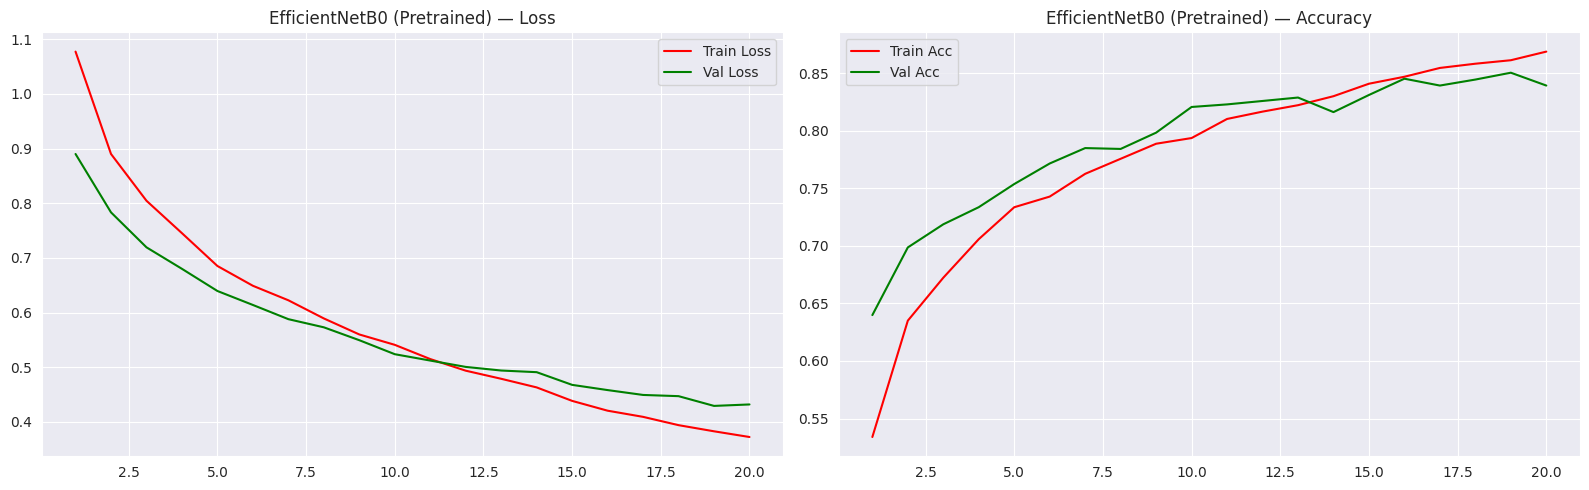

In [11]:
history_effnetb0 = effnetb0_model.fit(
    train_gen_eff, validation_data=val_gen_eff, epochs=HEAD_EPOCHS, verbose=1
)
plot_history(history_effnetb0, 'EfficientNetB0 (Pretrained)')


269/269 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step

=== EfficientNetB0 (Pretrained): Classification Report ===
                     precision    recall  f1-score   support

             Glioma       0.84      0.88      0.86       469
         Meningioma       0.82      0.89      0.85       569
No Tumor or Healthy       0.71      0.54      0.62       136
          Pituitary       0.88      0.67      0.76       171

           accuracy                           0.82      1345
          macro avg       0.81      0.74      0.77      1345
       weighted avg       0.82      0.82      0.82      1345



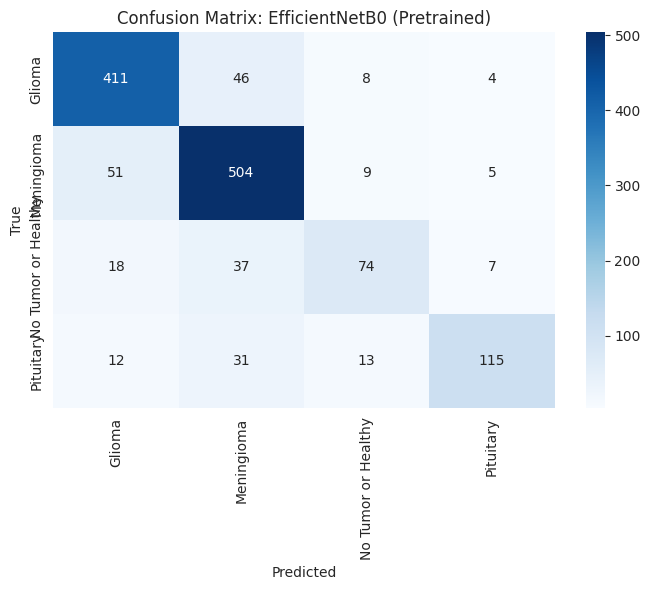

In [12]:
res = evaluate_model(effnetb0_model, test_gen_eff, test_steps_eff, class_names, 'EfficientNetB0 (Pretrained)')
results_pretrained.append(res)
effnetb0_model.save('EfficientNetB0_pretrained.keras')


## A.2 — VGG16 (Pretrained / Frozen)

In [13]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess

train_gen_vgg, val_gen_vgg, test_gen_vgg, test_steps_vgg = make_generators(vgg16_preprocess)

vgg16_model, vgg16_base = build_frozen_model(VGG16, model_name='VGG16_Pretrained')
vgg16_model.summary()


Found 6272 validated image filenames belonging to 4 classes.
Found 1344 validated image filenames belonging to 4 classes.
Found 1345 validated image filenames belonging to 4 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_Pretrained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 63s 134ms/step - accuracy: 0.4283 - loss: 2.0875 - val_accuracy: 0.5729 - val_loss: 1.0678
Epoch 2/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 52s 132ms/step - accuracy: 0.5305 - loss: 1.2314 - val_accuracy: 0.6310 - val_loss: 0.9285
Epoch 3/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - accuracy: 0.5826 - loss: 1.0169 - val_accuracy: 0.6570 - val_loss: 0.8650
Epoch 4/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 52s 132ms/step - accuracy: 0.6224 - loss: 0.8997 - val_accuracy: 0.6875 - val_loss: 0.8190
Epoch 5/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 52s 132ms/step - accuracy: 0.6481 - loss: 0.8327 - val_accuracy: 0.6778 - val_loss: 0.7919
Epoch 6/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - accuracy: 0.6838 - loss: 0.7715 - val_accuracy: 0.7024 - val_loss: 0.7492
Epoch 7/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 52s 132ms/step - accuracy: 0.7070 - loss: 0.7121 - val_accuracy: 0.7113 - val_loss: 0.7276
Epoch 8/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 52s 132ms/step - accuracy: 0.7325 - loss: 0

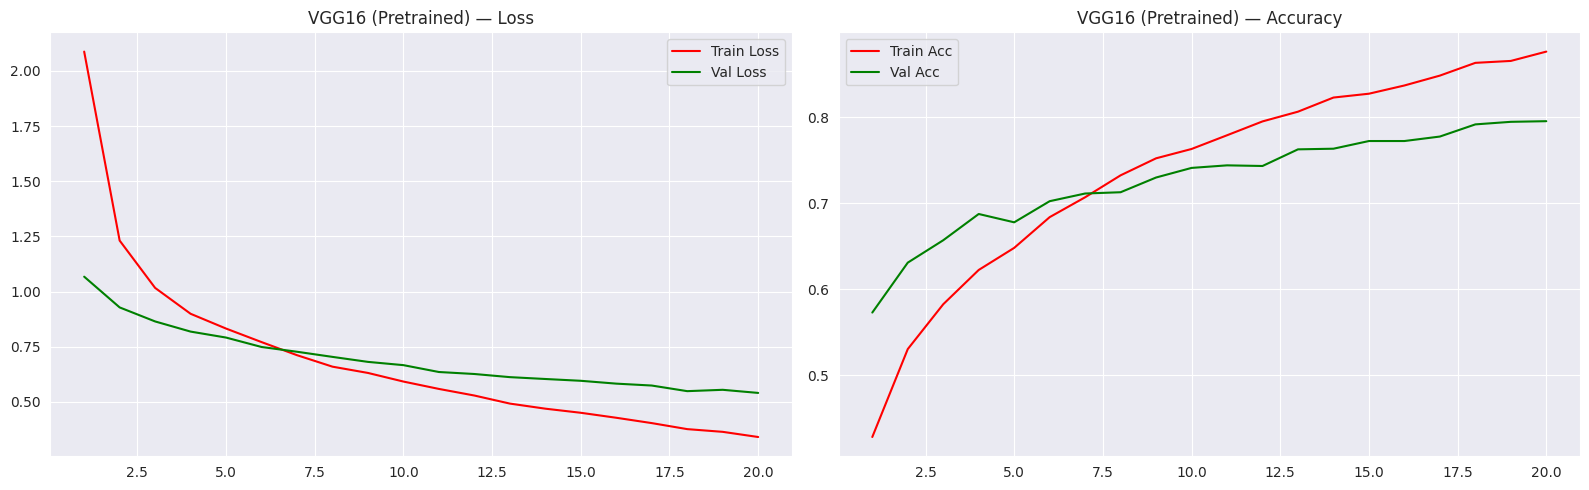

In [14]:
history_vgg16 = vgg16_model.fit(
    train_gen_vgg, validation_data=val_gen_vgg, epochs=HEAD_EPOCHS, verbose=1
)
plot_history(history_vgg16, 'VGG16 (Pretrained)')


269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step

=== VGG16 (Pretrained): Classification Report ===
                     precision    recall  f1-score   support

             Glioma       0.81      0.78      0.79       469
         Meningioma       0.76      0.84      0.80       569
No Tumor or Healthy       0.61      0.52      0.56       136
          Pituitary       0.81      0.72      0.76       171

           accuracy                           0.77      1345
          macro avg       0.75      0.71      0.73      1345
       weighted avg       0.77      0.77      0.77      1345



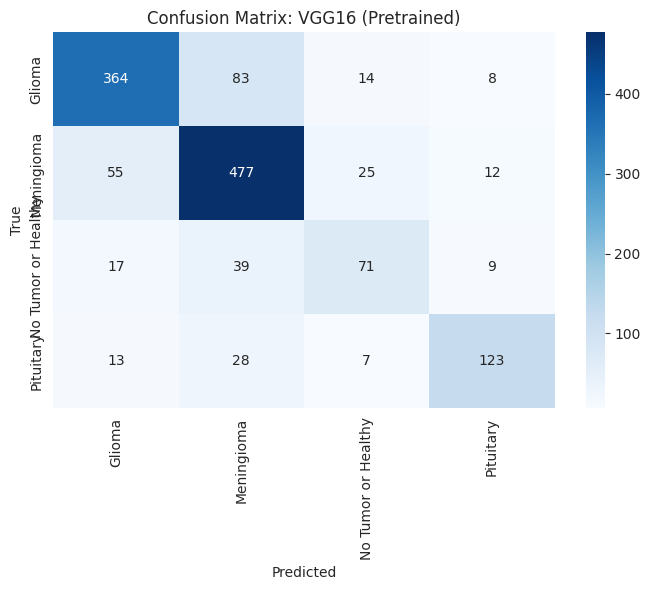

In [15]:
res = evaluate_model(vgg16_model, test_gen_vgg, test_steps_vgg, class_names, 'VGG16 (Pretrained)')
results_pretrained.append(res)
vgg16_model.save('VGG16_pretrained.keras')


## A.3 — ConvNeXt-Tiny (Pretrained / Frozen)

In [16]:
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess
# Note: ConvNeXt's Keras implementation normalises internally, so preprocess_input
# is effectively an identity function here — passed for pipeline consistency.

train_gen_cvx, val_gen_cvx, test_gen_cvx, test_steps_cvx = make_generators(convnext_preprocess)

convnext_model, convnext_base = build_frozen_model(ConvNeXtTiny, model_name='ConvNeXtTiny_Pretrained')
convnext_model.summary()


Found 6272 validated image filenames belonging to 4 classes.
Found 1344 validated image filenames belonging to 4 classes.
Found 1345 validated image filenames belonging to 4 classes.
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ConvNeXtTiny_Pretrained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,018,020 (106.88 MB)

 Trainable params: 197,892 (773.02 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

Epoch 1/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.4941 - loss: 1.1305 - val_accuracy: 0.6153 - val_loss: 0.9413
Epoch 2/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.6051 - loss: 0.9531 - val_accuracy: 0.6443 - val_loss: 0.8659
Epoch 3/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.6330 - loss: 0.8807 - val_accuracy: 0.6682 - val_loss: 0.8285
Epoch 4/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.6673 - loss: 0.8247 - val_accuracy: 0.6972 - val_loss: 0.7785
Epoch 5/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.6891 - loss: 0.7827 - val_accuracy: 0.7001 - val_loss: 0.7528
Epoch 6/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.7074 - loss: 0.7397 - val_accuracy: 0.7158 - val_loss: 0.7321
Epoch 7/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.7275 - loss: 0.7046 - val_accuracy: 0.7210 - val_loss: 0.7046
Epoch 8/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.7337 - loss: 0.6848 - 

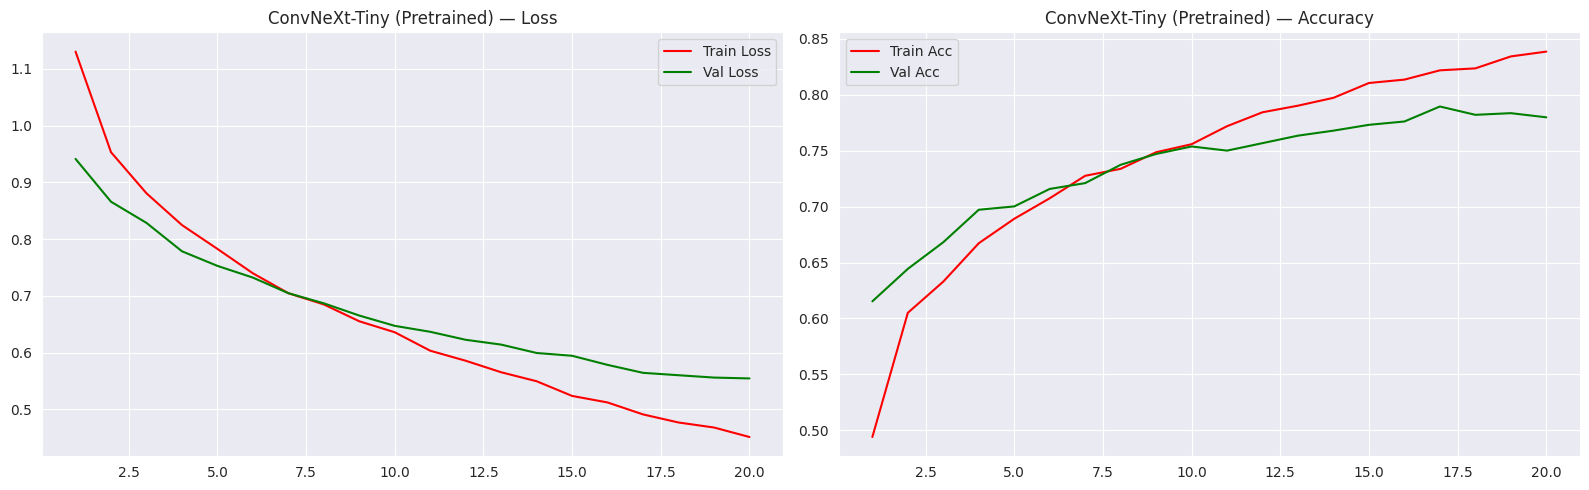

In [17]:
history_convnext = convnext_model.fit(
    train_gen_cvx, validation_data=val_gen_cvx, epochs=HEAD_EPOCHS, verbose=1
)
plot_history(history_convnext, 'ConvNeXt-Tiny (Pretrained)')


269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step

=== ConvNeXt-Tiny (Pretrained): Classification Report ===
                     precision    recall  f1-score   support

             Glioma       0.77      0.83      0.80       469
         Meningioma       0.75      0.84      0.79       569
No Tumor or Healthy       0.69      0.35      0.47       136
          Pituitary       0.83      0.62      0.71       171

           accuracy                           0.76      1345
          macro avg       0.76      0.66      0.69      1345
       weighted avg       0.76      0.76      0.75      1345



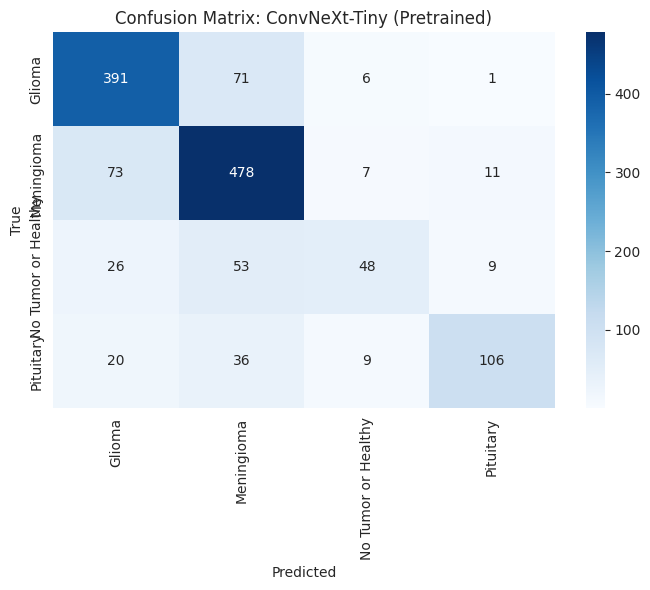

In [18]:
res = evaluate_model(convnext_model, test_gen_cvx, test_steps_cvx, class_names, 'ConvNeXt-Tiny (Pretrained)')
results_pretrained.append(res)
convnext_model.save('ConvNeXtTiny_pretrained.keras')


### Part A — Pretrained Results Table

In [19]:
pretrained_df = pd.DataFrame(results_pretrained)
pretrained_df


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,EfficientNetB0 (Pretrained),0.820818,0.819858,0.820818,0.816696
1,VGG16 (Pretrained),0.769517,0.768769,0.769517,0.767558
2,ConvNeXt-Tiny (Pretrained),0.760595,0.759741,0.760595,0.751174


---
# Part B — Fine-Tuned Models

Starting from each model above, the last `UNFREEZE_LAST_N` backbone layers are unfrozen and retrained at a lower learning rate (`FINETUNE_LR`), with everything else — data split, image size, batch size, epochs — held identical to Part A.

## B.1 — EfficientNetB0 (Fine-Tuned)

Trainable base layers: 30 / 238
Epoch 1/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - accuracy: 0.6813 - loss: 0.8015 - val_accuracy: 0.7693 - val_loss: 0.6132
Epoch 2/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.7376 - loss: 0.6651 - val_accuracy: 0.7969 - val_loss: 0.5657
Epoch 3/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.7664 - loss: 0.6029 - val_accuracy: 0.8043 - val_loss: 0.5328
Epoch 4/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.7771 - loss: 0.5666 - val_accuracy: 0.8065 - val_loss: 0.5064
Epoch 5/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.8009 - loss: 0.5239 - val_accuracy: 0.8222 - val_loss: 0.4830
Epoch 6/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.8133 - loss: 0.4942 - val_accuracy: 0.8281 - val_loss: 0.4710
Epoch 7/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.8166 - loss: 0.4829 - val_accuracy: 0.8274 - val_loss: 0.4557
Epoch 8/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - ac

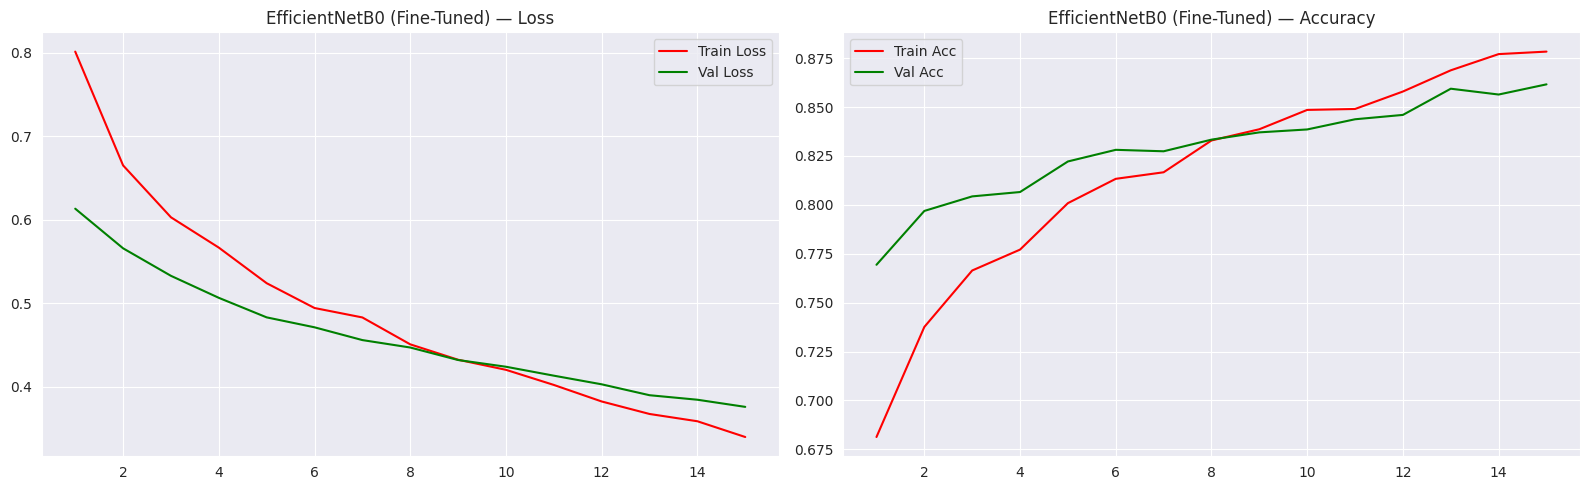

In [20]:
effnetb0_model = fine_tune_model(effnetb0_model, effnetb0_base)

history_effnetb0_ft = effnetb0_model.fit(
    train_gen_eff, validation_data=val_gen_eff, epochs=FINETUNE_EPOCHS, verbose=1
)
plot_history(history_effnetb0_ft, 'EfficientNetB0 (Fine-Tuned)')


269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step

=== EfficientNetB0 (Fine-Tuned): Classification Report ===
                     precision    recall  f1-score   support

             Glioma       0.85      0.87      0.86       469
         Meningioma       0.85      0.87      0.86       569
No Tumor or Healthy       0.66      0.64      0.65       136
          Pituitary       0.81      0.73      0.77       171

           accuracy                           0.83      1345
          macro avg       0.79      0.78      0.79      1345
       weighted avg       0.83      0.83      0.83      1345



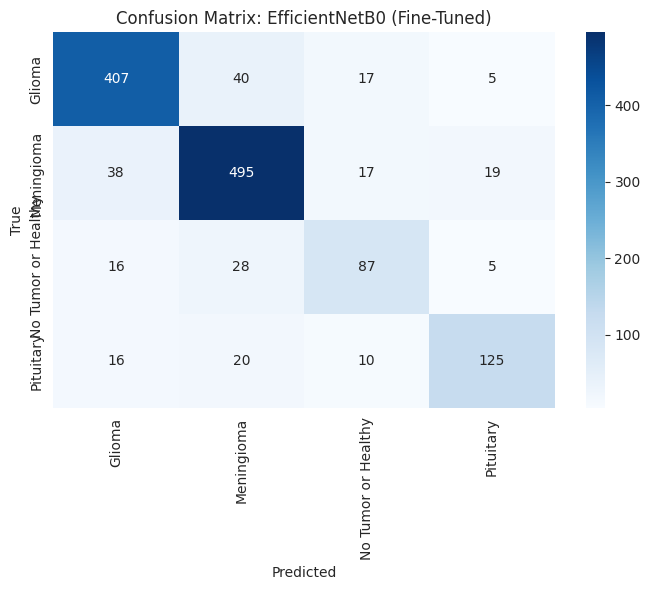

In [21]:
res = evaluate_model(effnetb0_model, test_gen_eff, test_steps_eff, class_names, 'EfficientNetB0 (Fine-Tuned)')
results_finetuned.append(res)
effnetb0_model.save('EfficientNetB0_finetuned.keras')


## B.2 — VGG16 (Fine-Tuned)

Trainable base layers: 19 / 19
Epoch 1/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 161s 323ms/step - accuracy: 0.8162 - loss: 0.4574 - val_accuracy: 0.7969 - val_loss: 0.5162
Epoch 2/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 126s 321ms/step - accuracy: 0.8734 - loss: 0.3387 - val_accuracy: 0.8214 - val_loss: 0.4877
Epoch 3/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 125s 320ms/step - accuracy: 0.9031 - loss: 0.2627 - val_accuracy: 0.8132 - val_loss: 0.4803
Epoch 4/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 126s 322ms/step - accuracy: 0.9236 - loss: 0.2113 - val_accuracy: 0.8408 - val_loss: 0.4308
Epoch 5/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 126s 322ms/step - accuracy: 0.9311 - loss: 0.1838 - val_accuracy: 0.8795 - val_loss: 0.3809
Epoch 6/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 125s 320ms/step - accuracy: 0.9434 - loss: 0.1557 - val_accuracy: 0.8624 - val_loss: 0.4267
Epoch 7/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 125s 319ms/step - accuracy: 0.9511 - loss: 0.1303 - val_accuracy: 0.8988 - val_loss: 0.3369
Epoch 8/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 126s 

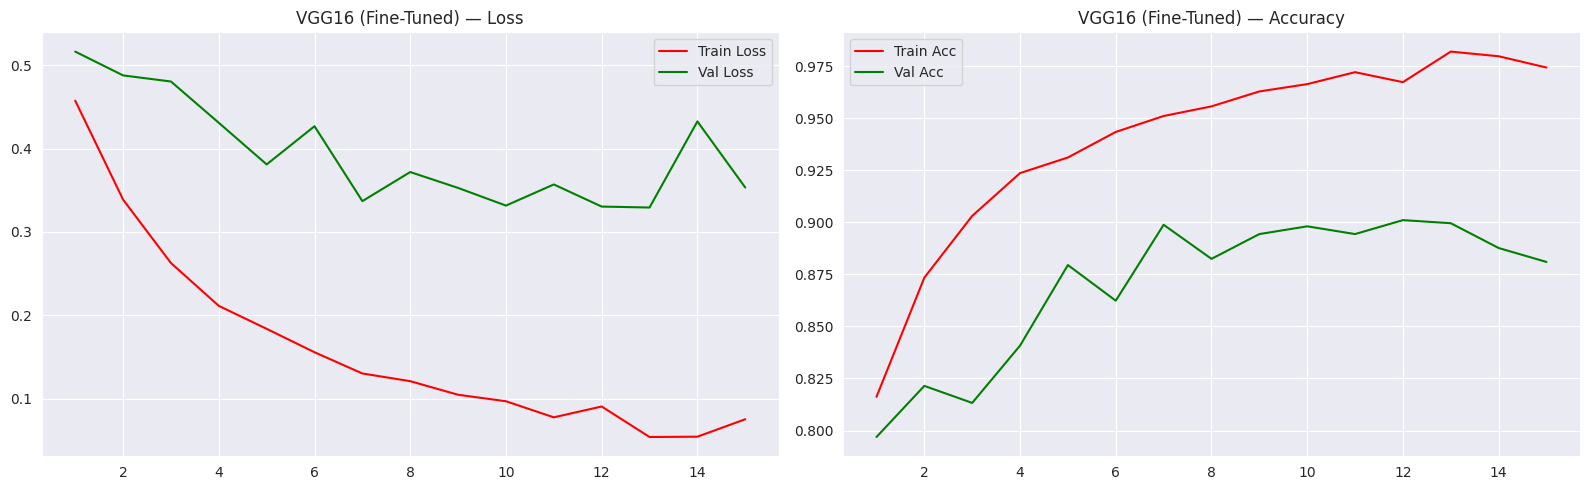

In [22]:
vgg16_model = fine_tune_model(vgg16_model, vgg16_base)

history_vgg16_ft = vgg16_model.fit(
    train_gen_vgg, validation_data=val_gen_vgg, epochs=FINETUNE_EPOCHS, verbose=1
)
plot_history(history_vgg16_ft, 'VGG16 (Fine-Tuned)')


269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step

=== VGG16 (Fine-Tuned): Classification Report ===
                     precision    recall  f1-score   support

             Glioma       0.85      0.95      0.90       469
         Meningioma       0.95      0.88      0.91       569
No Tumor or Healthy       0.76      0.85      0.81       136
          Pituitary       0.93      0.80      0.86       171

           accuracy                           0.89      1345
          macro avg       0.87      0.87      0.87      1345
       weighted avg       0.89      0.89      0.89      1345



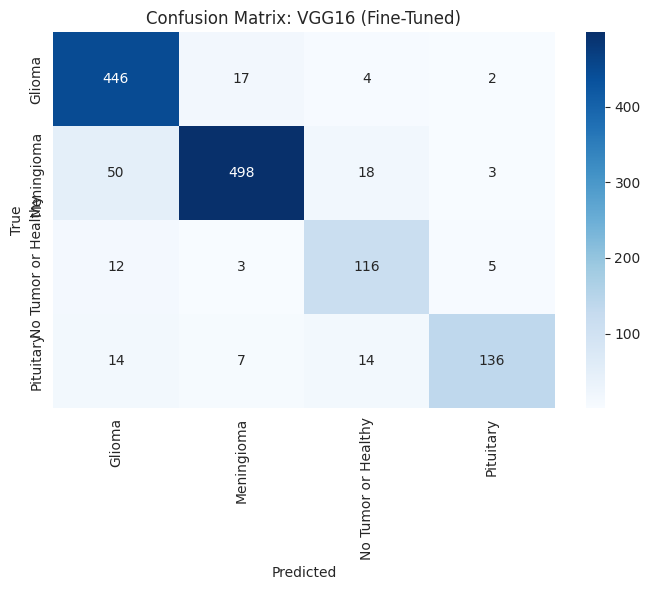

In [23]:
res = evaluate_model(vgg16_model, test_gen_vgg, test_steps_vgg, class_names, 'VGG16 (Fine-Tuned)')
results_finetuned.append(res)
vgg16_model.save('VGG16_finetuned.keras')


## B.3 — ConvNeXt-Tiny (Fine-Tuned)

Trainable base layers: 30 / 133
Epoch 1/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 99s 195ms/step - accuracy: 0.8546 - loss: 0.4191 - val_accuracy: 0.8036 - val_loss: 0.5014
Epoch 2/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 72s 182ms/step - accuracy: 0.8842 - loss: 0.3570 - val_accuracy: 0.8207 - val_loss: 0.4678
Epoch 3/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 71s 180ms/step - accuracy: 0.9032 - loss: 0.3038 - val_accuracy: 0.8311 - val_loss: 0.4358
Epoch 4/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 71s 182ms/step - accuracy: 0.9276 - loss: 0.2585 - val_accuracy: 0.8415 - val_loss: 0.4190
Epoch 5/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 71s 180ms/step - accuracy: 0.9401 - loss: 0.2233 - val_accuracy: 0.8430 - val_loss: 0.4073
Epoch 6/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 71s 180ms/step - accuracy: 0.9557 - loss: 0.1874 - val_accuracy: 0.8586 - val_loss: 0.3772
Epoch 7/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 71s 181ms/step - accuracy: 0.9668 - loss: 0.1578 - val_accuracy: 0.8586 - val_loss: 0.3614
Epoch 8/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 71s 181ms/s

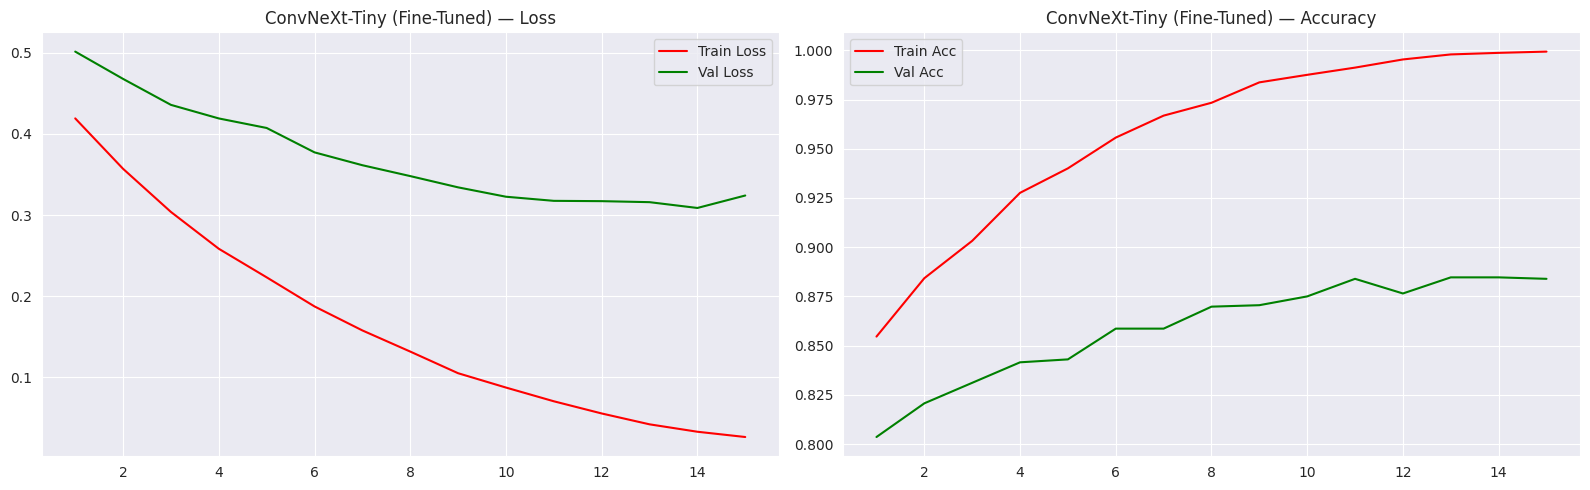

In [24]:
convnext_model = fine_tune_model(convnext_model, convnext_base)

history_convnext_ft = convnext_model.fit(
    train_gen_cvx, validation_data=val_gen_cvx, epochs=FINETUNE_EPOCHS, verbose=1
)
plot_history(history_convnext_ft, 'ConvNeXt-Tiny (Fine-Tuned)')


269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step

=== ConvNeXt-Tiny (Fine-Tuned): Classification Report ===
                     precision    recall  f1-score   support

             Glioma       0.92      0.87      0.89       469
         Meningioma       0.84      0.95      0.89       569
No Tumor or Healthy       0.81      0.65      0.72       136
          Pituitary       0.88      0.79      0.83       171

           accuracy                           0.87      1345
          macro avg       0.86      0.81      0.83      1345
       weighted avg       0.87      0.87      0.87      1345



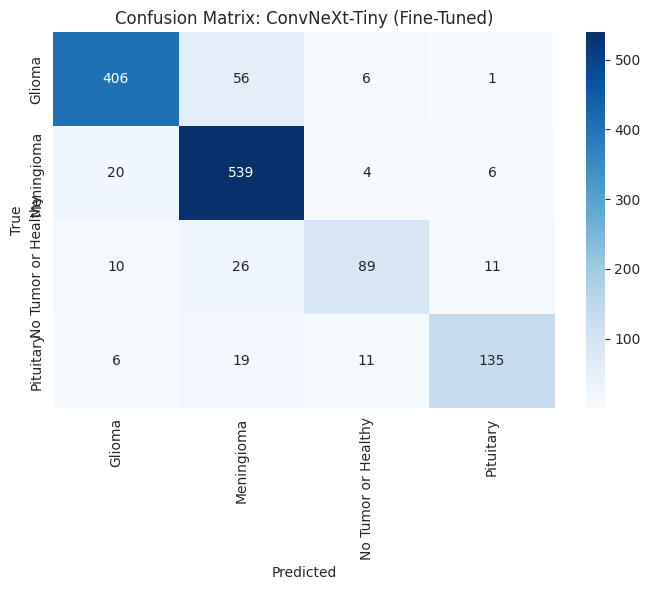

In [25]:
res = evaluate_model(convnext_model, test_gen_cvx, test_steps_cvx, class_names, 'ConvNeXt-Tiny (Fine-Tuned)')
results_finetuned.append(res)
convnext_model.save('ConvNeXtTiny_finetuned.keras')


---
# Final Comparison — Pretrained vs Fine-Tuned

In [26]:
finetuned_df = pd.DataFrame(results_finetuned)

comparison_df = pretrained_df.copy()
comparison_df['stage'] = 'Pretrained (Frozen)'
ft_copy = finetuned_df.copy()
ft_copy['stage'] = 'Fine-Tuned'

final_comparison = pd.concat([comparison_df, ft_copy], ignore_index=True)
final_comparison = final_comparison[['model', 'stage', 'accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']]
final_comparison = final_comparison.round(4)
final_comparison


,model,stage,accuracy,precision_weighted,recall_weighted,f1_weighted
0,EfficientNetB0 (Pretrained),Pretrained (Frozen),0.8208,0.8199,0.8208,0.8167
1,VGG16 (Pretrained),Pretrained (Frozen),0.7695,0.7688,0.7695,0.7676
2,ConvNeXt-Tiny (Pretrained),Pretrained (Frozen),0.7606,0.7597,0.7606,0.7512
3,EfficientNetB0 (Fine-Tuned),Fine-Tuned,0.8283,0.8271,0.8283,0.8273
4,VGG16 (Fine-Tuned),Fine-Tuned,0.8892,0.8948,0.8892,0.8896
5,ConvNeXt-Tiny (Fine-Tuned),Fine-Tuned,0.8691,0.8706,0.8691,0.8671


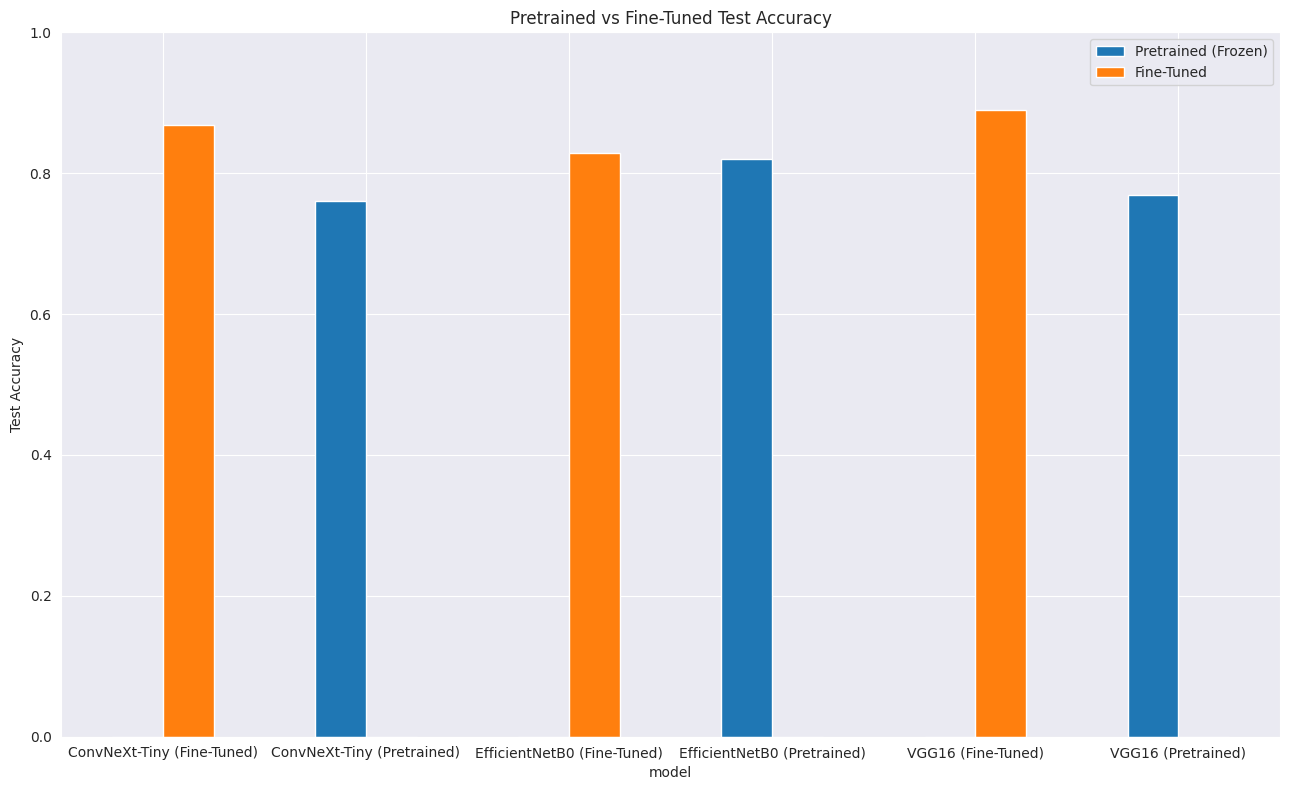

In [27]:
# Simple bar chart comparing test accuracy: Pretrained vs Fine-Tuned, per model
pivot = final_comparison.pivot(index='model', columns='stage', values='accuracy')
pivot = pivot[['Pretrained (Frozen)', 'Fine-Tuned']]
pivot.plot(kind='bar', figsize=(13, 8), rot=0)
plt.ylabel('Test Accuracy')
plt.title('Pretrained vs Fine-Tuned Test Accuracy')
plt.ylim(0, 1)
plt.legend(title='')
plt.tight_layout()
plt.show()


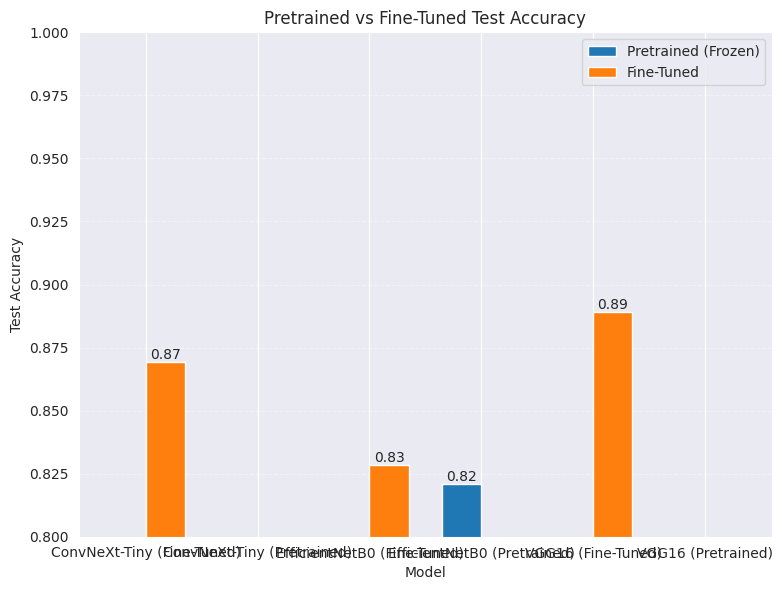

In [28]:
# Simple bar chart comparing test accuracy: Pretrained vs Fine-Tuned, per model

pivot = final_comparison.pivot(index='model', columns='stage', values='accuracy')
pivot = pivot[['Pretrained (Frozen)', 'Fine-Tuned']]

# Shorter model names
pivot = pivot.rename(index={
    'ConvNeXt-Tiny': 'ConvNeXt',
    'EfficientNetB0': 'EffNetB0'
})

ax = pivot.plot(
    kind='bar',
    figsize=(8,6),
    width=0.7,
    rot=0
)

plt.title('Pretrained vs Fine-Tuned Test Accuracy')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0.80, 1.00)
plt.legend(title='')

# Show accuracy values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()